# Feature Selection

The original dataset contains 24,526 gene expression features.

To reduce dimensionality and improve model performance,
ANOVA F-Test based SelectKBest was used.

Top 500 important features were selected for training.

In [7]:
import pandas as pd

df = pd.read_csv(
    "../dataset/final_ml_dataset.csv"
)

df.head()

,Sample,ILMN_1762337,ILMN_2055271,ILMN_2383229,ILMN_1806310,ILMN_1779670,ILMN_2321282,ILMN_1772582,ILMN_1717783,ILMN_1814316,...,ILMN_1685547,ILMN_2348512,ILMN_1743643,ILMN_1723439,ILMN_1656676,ILMN_2371169,ILMN_1701875,ILMN_1786396,ILMN_2137536,Label
0,N1,1576.590,45.57935,34.79572,60.56178,46.19312,45.66373,197.44550,33.07355,626.90220,...,3460.527,417.5961,4099.982,133.02100,6274.076,418.7008,658.5944,1242.3610,5000.303,0
1,N2,1182.878,60.13985,92.37458,107.53330,55.48008,40.18997,44.08770,44.42251,389.61870,...,3007.432,475.0391,2424.271,66.32084,5614.740,251.9211,593.5541,635.0237,5045.851,0
2,N3,1520.327,66.13029,39.98098,49.67543,48.03688,33.45635,62.81656,47.94210,410.59770,...,3508.441,201.3734,3530.509,55.38755,4774.403,406.2433,791.8285,1317.7720,5500.245,0
3,N4,1894.716,62.59804,50.13279,49.55871,59.52765,50.61895,60.22463,52.33357,251.54920,...,5843.146,328.5837,4466.550,51.06415,5445.089,710.5341,1306.6890,2013.7850,6607.648,0
4,N5,1098.504,56.82548,43.82329,52.66096,48.49674,42.91734,48.83210,48.49342,59.64558,...,5605.192,334.3158,5336.203,48.23994,6164.642,664.9867,1887.2610,2047.8650,6455.382,0


In [8]:
X = df.drop(
    ["Sample", "Label"],
    axis=1
)

y = df["Label"]

print(
    "Original Features:",
    X.shape[1]
)

Original Features: 24526


In [9]:
from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

selector = SelectKBest(
    score_func=f_classif,
    k=500
)

X_selected = selector.fit_transform(
    X,
    y
)

print(
    "Selected Features:",
    X_selected.shape[1]
)

Selected Features: 500


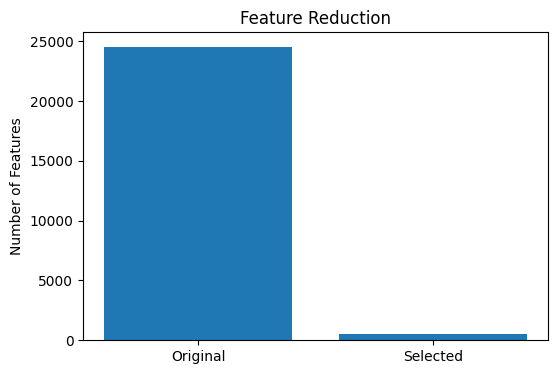

In [10]:
import matplotlib.pyplot as plt

features = [
    X.shape[1],
    X_selected.shape[1]
]

labels = [
    "Original",
    "Selected"
]

plt.figure(figsize=(6,4))

plt.bar(
    labels,
    features
)

plt.title(
    "Feature Reduction"
)

plt.ylabel(
    "Number of Features"
)

plt.show()

In [11]:
selected_columns = X.columns[
    selector.get_support()
]

selected_columns[:20]

Index(['ILMN_1700461', 'ILMN_1776119', 'ILMN_1658083', 'ILMN_1738921',
       'ILMN_2225595', 'ILMN_2352009', 'ILMN_1679600', 'ILMN_1691714',
       'ILMN_1663132', 'ILMN_1700349', 'ILMN_2148944', 'ILMN_2257015',
       'ILMN_1717357', 'ILMN_1797974', 'ILMN_1712530', 'ILMN_2396691',
       'ILMN_2380771', 'ILMN_1690252', 'ILMN_2199284', 'ILMN_1803779'],
      dtype='str')

In [12]:
selected_df = pd.DataFrame(
    X_selected,
    columns=selected_columns
)

selected_df["Label"] = y

selected_df.head()

,ILMN_1700461,ILMN_1776119,ILMN_1658083,ILMN_1738921,ILMN_2225595,ILMN_2352009,ILMN_1679600,ILMN_1691714,ILMN_1663132,ILMN_1700349,...,ILMN_1672940,ILMN_2078141,ILMN_1654612,ILMN_1698048,ILMN_2171640,ILMN_1670640,ILMN_2045175,ILMN_1800750,ILMN_2175447,Label
0,935.6070,234.3474,118.2800,893.8805,592.6266,374.2499,185.0592,163.18570,1589.801,103.54250,...,333.9715,458.4577,836.6818,201.1774,221.9025,111.72160,198.4151,712.3456,1163.6610,0
1,977.2614,145.9691,109.0556,644.9527,570.0883,507.2513,358.0979,198.91040,2594.574,134.12930,...,228.6719,377.9895,1905.3080,170.5912,173.0880,97.06413,188.7685,1317.0420,2195.4550,0
2,983.6641,257.5760,106.1608,712.3958,618.5681,395.5662,180.6711,64.65596,1119.165,74.19514,...,184.3754,272.9053,1132.6740,123.8508,152.4242,83.12721,193.6905,621.4002,1192.7820,0
3,1600.8570,307.8341,130.4562,1260.5380,797.9879,755.7017,328.9742,187.57900,3637.393,132.63230,...,310.4337,518.6738,1297.1330,175.4108,210.0579,121.11830,334.0703,2405.5520,1790.9140,0
4,1412.7820,400.2456,131.5690,755.1400,505.1268,655.3365,347.9955,191.31880,1811.977,73.71181,...,505.9775,296.5089,892.4323,126.5319,174.2380,83.72725,210.2115,1444.1460,989.1553,0


## Conclusion

Original Features : 24,526

Selected Features : 500

Feature selection reduced computational complexity
and retained the most informative genes for oral
cancer prediction.